<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/17_custom_dropout_normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 17 — Custom Dropout & Custom Normalization

## What This Notebook Covers
This notebook builds advanced custom components from scratch,
following the patterns from Aurélien Géron's Hands-On ML Chapter 11.

**Components built:**
- `MCAlphaDropout` — Monte Carlo version of Alpha Dropout
  (designed for SELU self-normalizing networks)
- `MaxNormDense` — Dense layer with a max-norm constraint on weights
  (prevents any weight from growing too large)
- `LayerNormDense` — Dense layer with built-in layer normalization
- Custom constraint class — reusable weight constraints

**Key concepts:**
- Alpha Dropout preserves mean and variance of SELU activations
- Max-norm constrains the L2 norm of each weight vector
- Both are applied post-training for uncertainty (MC) or during
  training for regularization (MaxNorm)

**Both TensorFlow and PyTorch shown.**

**Dataset:** Fashion-MNIST


In [1]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [2]:
# TensorFlow
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]
print('TF data ready.')

# PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set_pt, valid_set_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set_pt, batch_size=64, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_set_pt,  batch_size=64, shuffle=False, pin_memory=True)
print('PyTorch data ready.')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
TF data ready.


100%|██████████| 26.4M/26.4M [00:00<00:00, 117MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 5.00MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 66.5MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 32.1MB/s]


PyTorch data ready.


---
## Part A — TensorFlow / Keras

## 2. Background: SELU and Alpha Dropout

**SELU (Scaled Exponential Linear Unit)** is a self-normalizing activation.
When inputs are standardized and weights are LeCun-initialized,
SELU drives activations toward zero mean and unit variance automatically —
without needing BatchNorm.

Standard dropout breaks SELU's self-normalizing property because
zeroing activations shifts the mean. **Alpha Dropout** was designed
specifically for SELU: instead of zeroing, it replaces dropped values
with a carefully chosen negative saturation value, then applies
an affine transform to restore the original mean and variance.

**MCAlphaDropout** keeps Alpha Dropout active at inference time
to get uncertainty estimates (the MC Dropout idea from Notebook 03,
but designed for SELU networks).


In [3]:
class MCAlphaDropout(tf.keras.layers.Layer):
    """
    Monte Carlo Alpha Dropout — always active, even at inference.

    Alpha Dropout is dropout designed for SELU activations:
    - Standard dropout zeroes activations -> shifts mean away from 0
    - Alpha Dropout replaces dropped values with the SELU saturation
      value (-alpha * scale = -1.7581) then applies an affine
      rescaling to restore mean=0 and variance=1
    - This preserves SELU's self-normalizing property

    By always keeping it active (training=True), we get MC Dropout
    uncertainty estimation for SELU networks.

    Reference: Klambauer et al. 2017 'Self-Normalizing Neural Networks'
    """
    def __init__(self, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate
        # Wrap Keras AlphaDropout — we always call it with training=True
        self.alpha_dropout = tf.keras.layers.AlphaDropout(rate)

    def call(self, inputs, training=None):
        # KEY: always pass training=True so dropout stays active at inference
        return self.alpha_dropout(inputs, training=True)

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config


# Verify: output should vary across calls (dropout is always active)
mc_drop = MCAlphaDropout(rate=0.2)
test_input = tf.ones((3, 8))

out1 = mc_drop(test_input).numpy()
out2 = mc_drop(test_input).numpy()

print('MCAlphaDropout: outputs differ across calls (dropout always on):')
print('Run 1:', out1[0].round(3))
print('Run 2:', out2[0].round(3))
print('Are they identical?', np.allclose(out1, out2))
print()
print('Mean preservation check (Alpha Dropout restores mean~0):')
# Use standardized input to test mean preservation
std_input = tf.random.normal((1000, 100))
outputs   = mc_drop(std_input)
print(f'  Input  mean: {tf.reduce_mean(std_input).numpy():.4f}  (expect ~0)')
print(f'  Output mean: {tf.reduce_mean(outputs).numpy():.4f}  (Alpha Dropout restores this)')

MCAlphaDropout: outputs differ across calls (dropout always on):
Run 1: [ 1.188  1.188  1.188 -1.236  1.188  1.188 -1.236  1.188]
Run 2: [ 1.188  1.188  1.188  1.188  1.188  1.188  1.188 -1.236]
Are they identical? False

Mean preservation check (Alpha Dropout restores mean~0):
  Input  mean: -0.0008  (expect ~0)
  Output mean: -0.0016  (Alpha Dropout restores this)


## 3. SELU Network with MCAlphaDropout

SELU networks have strict requirements:
- Activation: `selu`
- Initializer: `lecun_normal` (not he_normal)
- Input: must be standardized (zero mean, unit variance)
- Dropout: `AlphaDropout` (not standard Dropout)
- No BatchNorm needed — SELU self-normalizes


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ReLU + BatchNorm + Dropout (baseline)         -> best val acc: 0.8856
SELU + LeCun + MCAlphaDropout                 -> best val acc: 0.8898


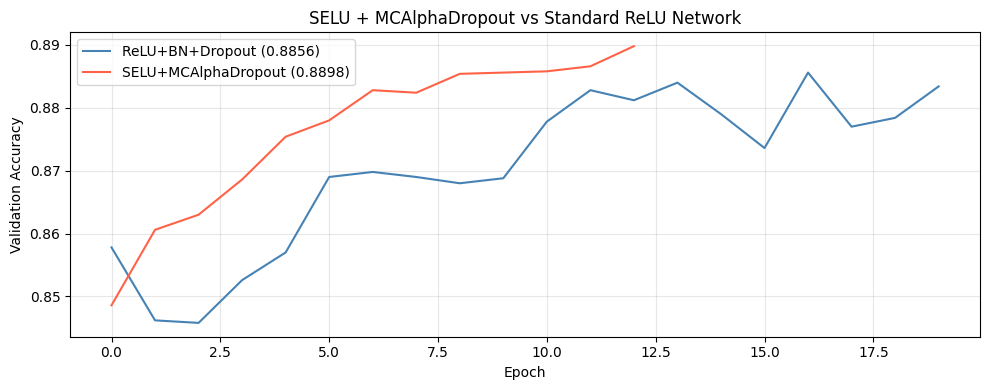

In [4]:
def make_selu_model_with_mc_dropout(rate=0.1):
    """
    Self-normalizing network using SELU + LeCun init + MCAlphaDropout.
    Note: no BatchNorm — SELU handles normalization automatically.
    """
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        # lecun_normal init is required for SELU self-normalization
        tf.keras.layers.Dense(300, activation='selu',
                               kernel_initializer='lecun_normal'),
        MCAlphaDropout(rate),
        tf.keras.layers.Dense(200, activation='selu',
                               kernel_initializer='lecun_normal'),
        MCAlphaDropout(rate),
        tf.keras.layers.Dense(100, activation='selu',
                               kernel_initializer='lecun_normal'),
        MCAlphaDropout(rate * 0.5),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def make_standard_model():
    """Baseline: ReLU + BatchNorm + standard Dropout."""
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(200, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(100, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def compile_and_train(model, label, epochs=20):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    h = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True)],
        verbose=0
    )
    best = max(h.history['val_accuracy'])
    print(f'{label:45s} -> best val acc: {best:.4f}')
    return h


tf.random.set_seed(42)
h_standard = compile_and_train(make_standard_model(),
                                 'ReLU + BatchNorm + Dropout (baseline)')

tf.random.set_seed(42)
h_selu = compile_and_train(make_selu_model_with_mc_dropout(rate=0.1),
                            'SELU + LeCun + MCAlphaDropout')

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(h_standard.history['val_accuracy'], color='steelblue',
         label=f'ReLU+BN+Dropout ({max(h_standard.history["val_accuracy"]):.4f})')
plt.plot(h_selu.history['val_accuracy'],     color='tomato',
         label=f'SELU+MCAlphaDropout ({max(h_selu.history["val_accuracy"]):.4f})')
plt.title('SELU + MCAlphaDropout vs Standard ReLU Network')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. MC Inference with MCAlphaDropout

Since MCAlphaDropout is always active, we can run N forward passes
to get uncertainty estimates — same as Notebook 03, but for SELU nets.


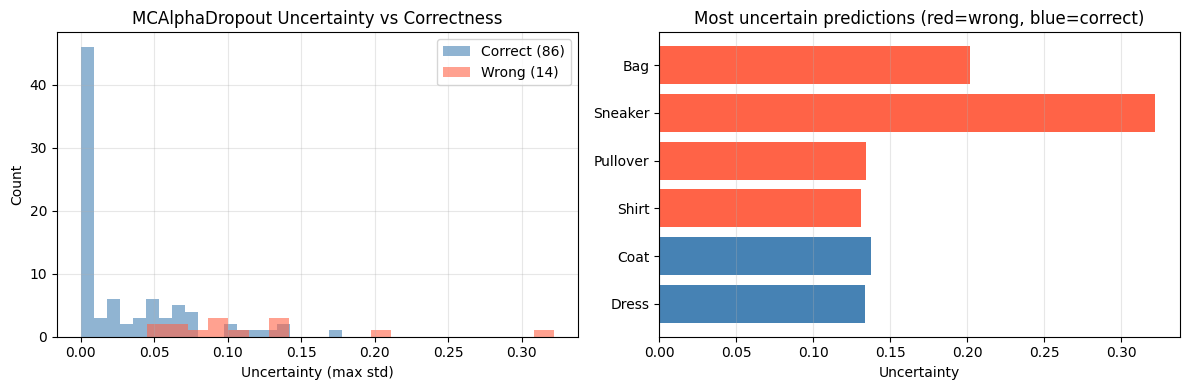

Mean uncertainty — correct  : 0.0294
Mean uncertainty — incorrect: 0.1162


In [5]:
selu_model = make_selu_model_with_mc_dropout(rate=0.1)
selu_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
selu_model.fit(X_train, y_train,
                validation_data=(X_valid, y_valid),
                epochs=15, batch_size=64, verbose=0)


def mc_predict(model, X, n_samples=50):
    """
    Run N stochastic forward passes.
    MCAlphaDropout stays active automatically — no training=True needed.
    """
    # Note: no training=True needed — MCAlphaDropout ignores the flag
    all_preds = np.stack(
        [model.predict(X, verbose=0) for _ in range(n_samples)],
        axis=0
    )  # (N, batch, 10)
    return all_preds.mean(axis=0), all_preds.std(axis=0)


CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Get uncertainty on 100 test samples
mean_preds, std_preds = mc_predict(selu_model, X_test[:100], n_samples=50)
uncertainty = std_preds.max(axis=1)
preds       = mean_preds.argmax(axis=1)
correct     = (preds == y_test[:100])

# Plot uncertainty distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(uncertainty[correct],  bins=20, alpha=0.6,
             color='steelblue', label=f'Correct ({correct.sum()})')
axes[0].hist(uncertainty[~correct], bins=20, alpha=0.6,
             color='tomato',    label=f'Wrong ({(~correct).sum()})')
axes[0].set_xlabel('Uncertainty (max std)')
axes[0].set_ylabel('Count')
axes[0].set_title('MCAlphaDropout Uncertainty vs Correctness')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Show most uncertain samples
top_unc_idx = uncertainty.argsort()[-10:]
axes[1].barh([CLASS_NAMES[y_test[i]] for i in top_unc_idx],
              uncertainty[top_unc_idx],
              color=['tomato' if not correct[i] else 'steelblue'
                     for i in top_unc_idx])
axes[1].set_xlabel('Uncertainty')
axes[1].set_title('Most uncertain predictions (red=wrong, blue=correct)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print(f'Mean uncertainty — correct  : {uncertainty[correct].mean():.4f}')
print(f'Mean uncertainty — incorrect: {uncertainty[~correct].mean():.4f}')

## 5. MaxNormDense — Dense Layer with Max-Norm Constraint

**Max-norm regularization** constrains the L2 norm of each weight
vector to be at most `max_norm`. After every gradient update,
any weight vector that exceeds the threshold is rescaled back.

Unlike L2 regularization (which adds a penalty), max-norm is a
**hard constraint** — weight norms are never allowed to exceed the limit.
This prevents exploding weights while allowing large learning rates.

Hinton et al. showed it works especially well with Dropout.


In [6]:
class MaxNormDense(tf.keras.layers.Layer):
    """
    Dense layer with a max-norm constraint on the kernel weights.

    After each gradient update, any column of the weight matrix
    whose L2 norm exceeds max_norm is rescaled so its norm equals max_norm.

    This is implemented via tf.keras.constraints.MaxNorm, applied
    as the kernel_constraint argument to the inner Dense layer.

    Unlike L2 regularization which softly penalizes large weights,
    max-norm is a HARD constraint — weight norms are clipped, not penalized.
    """
    def __init__(self, units, activation=None, max_norm=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.activation = activation
        self.max_norm   = max_norm

        # tf.keras.constraints.MaxNorm clips each weight vector's L2 norm
        self.dense = tf.keras.layers.Dense(
            units,
            activation=activation,
            kernel_initializer='he_normal',
            kernel_constraint=tf.keras.constraints.MaxNorm(max_value=max_norm,
                                                            axis=0)
            # axis=0: apply constraint to each column (each output unit's weights)
        )

    def call(self, inputs):
        return self.dense(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': self.activation,
            'max_norm': self.max_norm
        })
        return config


# Verify the constraint works
layer = MaxNormDense(64, activation='relu', max_norm=1.0)
_ = layer(tf.zeros([1, 32]))  # build the layer

weights = layer.dense.kernel.numpy()  # shape (32, 64)
col_norms = np.linalg.norm(weights, axis=0)

print('MaxNormDense constraint verification:')
print(f'  Weight matrix shape: {weights.shape}  (in_features x units)')
print(f'  Max column L2 norm BEFORE training: {col_norms.max():.4f}')
print(f'  All norms <= 1.0? {(col_norms <= 1.001).all()}')
print()

# Simulate a gradient update that would violate the constraint
# Then show that Keras clips it back
print('After simulated large update, constraint clips weights back...')
with tf.GradientTape() as tape:
    out  = layer(tf.random.normal([32, 32]))
    loss = tf.reduce_mean(out ** 2)
grads = tape.gradient(loss, layer.trainable_variables)

# Apply large gradient update
optimizer = tf.keras.optimizers.SGD(learning_rate=100.0)  # huge LR
optimizer.apply_gradients(zip(grads, layer.trainable_variables))

weights_after = layer.dense.kernel.numpy()
col_norms_after = np.linalg.norm(weights_after, axis=0)
print(f'  Max column L2 norm AFTER large update: {col_norms_after.max():.4f}')
print(f'  Constraint holds (all <= 1.0)? {(col_norms_after <= 1.001).all()}')

MaxNormDense constraint verification:
  Weight matrix shape: (32, 64)  (in_features x units)
  Max column L2 norm BEFORE training: 1.7801
  All norms <= 1.0? False

After simulated large update, constraint clips weights back...
  Max column L2 norm AFTER large update: 1.0000
  Constraint holds (all <= 1.0)? True


## 6. A/B Test: MaxNorm vs Standard Dense


Dense + Dropout(0.5)                          -> best val acc: 0.8848
MaxNormDense + Dropout(0.5)                   -> best val acc: 0.8800


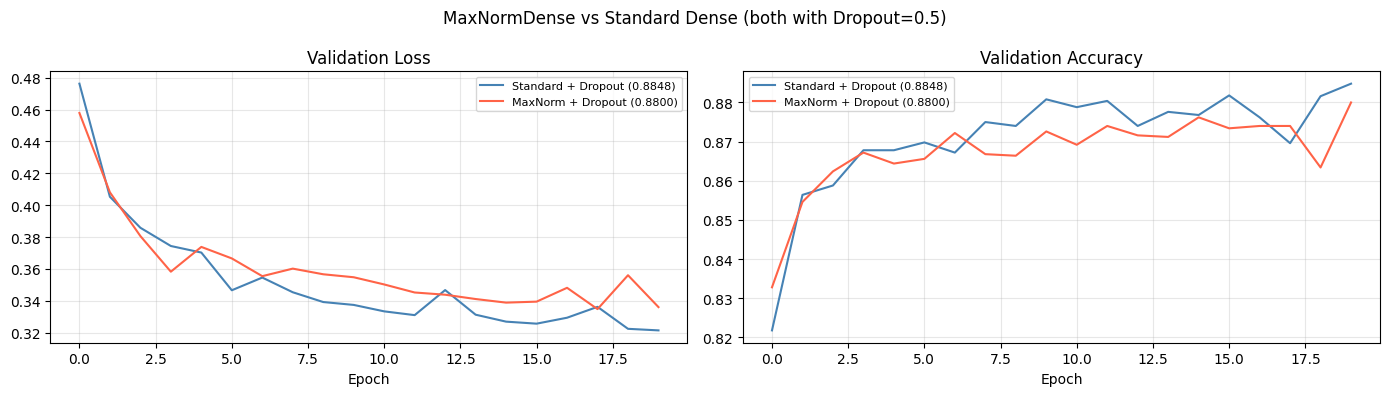

In [7]:
def make_maxnorm_model(max_norm=2.0, dropout_rate=0.5):
    """
    Network using MaxNormDense layers.
    Max-norm works especially well combined with high dropout rates
    (Srivastava et al. showed this combination in the original Dropout paper).
    """
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        MaxNormDense(300, activation='relu', max_norm=max_norm),
        tf.keras.layers.Dropout(dropout_rate),
        MaxNormDense(200, activation='relu', max_norm=max_norm),
        tf.keras.layers.Dropout(dropout_rate),
        MaxNormDense(100, activation='relu', max_norm=max_norm),
        tf.keras.layers.Dropout(dropout_rate * 0.6),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def make_standard_dropout_model(dropout_rate=0.5):
    """Standard Dense + Dropout without max-norm constraint."""
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(300, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(200, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(100, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.Dropout(dropout_rate * 0.6),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


tf.random.set_seed(42)
h_std_drop = compile_and_train(make_standard_dropout_model(0.5),
                                'Dense + Dropout(0.5)')

tf.random.set_seed(42)
h_maxnorm  = compile_and_train(make_maxnorm_model(max_norm=2.0, dropout_rate=0.5),
                                'MaxNormDense + Dropout(0.5)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(h_std_drop.history[f'val_{metric}'], color='steelblue',
            label=f'Standard + Dropout ({max(h_std_drop.history["val_accuracy"]):.4f})')
    ax.plot(h_maxnorm.history[f'val_{metric}'],  color='tomato',
            label=f'MaxNorm + Dropout ({max(h_maxnorm.history["val_accuracy"]):.4f})')
    ax.set_title(f'Validation {title}')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('MaxNormDense vs Standard Dense (both with Dropout=0.5)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Visualising Weight Norms Over Training

We track the weight column norms during training to verify that
MaxNorm genuinely clips them and StandardDense does not.


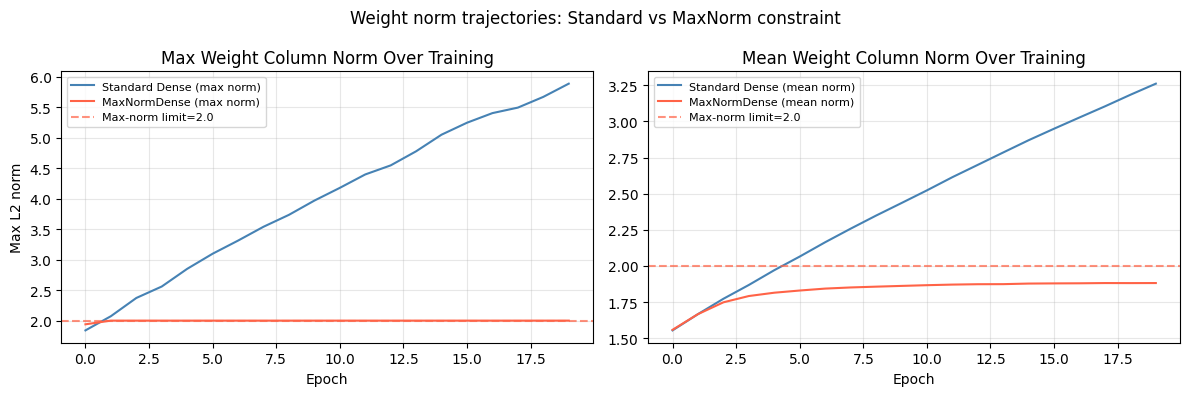

Standard Dense: weight norms grow freely.
MaxNormDense  : weight norms are clipped at 2.0 (the hard constraint).


In [8]:
class WeightNormTracker(tf.keras.callbacks.Callback):
    """
    Records the max weight column norm of the first Dense/MaxNormDense
    layer at the end of each epoch.
    """
    def __init__(self):
        super().__init__()
        self.max_norms = []
        self.mean_norms = []

    def on_epoch_end(self, epoch, logs=None):
        # Find the first layer with a kernel
        for layer in self.model.layers:
            if hasattr(layer, 'kernel'):
                w = layer.kernel.numpy()
            elif hasattr(layer, 'dense') and hasattr(layer.dense, 'kernel'):
                w = layer.dense.kernel.numpy()
            else:
                continue
            norms = np.linalg.norm(w, axis=0)
            self.max_norms.append(norms.max())
            self.mean_norms.append(norms.mean())
            break


EPOCHS = 20

# Standard model
tf.random.set_seed(42)
model_std = make_standard_dropout_model(0.5)
model_std.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
tracker_std = WeightNormTracker()
model_std.fit(X_train, y_train, epochs=EPOCHS, batch_size=64,
               callbacks=[tracker_std], verbose=0)

# MaxNorm model
tf.random.set_seed(42)
model_mn = make_maxnorm_model(max_norm=2.0, dropout_rate=0.5)
model_mn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
tracker_mn = WeightNormTracker()
model_mn.fit(X_train, y_train, epochs=EPOCHS, batch_size=64,
              callbacks=[tracker_mn], verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tracker_std.max_norms,  color='steelblue', label='Standard Dense (max norm)')
axes[0].plot(tracker_mn.max_norms,   color='tomato',    label='MaxNormDense (max norm)')
axes[0].axhline(2.0, color='tomato', linestyle='--', alpha=0.7, label='Max-norm limit=2.0')
axes[0].set_title('Max Weight Column Norm Over Training')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Max L2 norm')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(tracker_std.mean_norms, color='steelblue', label='Standard Dense (mean norm)')
axes[1].plot(tracker_mn.mean_norms,  color='tomato',    label='MaxNormDense (mean norm)')
axes[1].axhline(2.0, color='tomato', linestyle='--', alpha=0.7, label='Max-norm limit=2.0')
axes[1].set_title('Mean Weight Column Norm Over Training')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Weight norm trajectories: Standard vs MaxNorm constraint', fontsize=12)
plt.tight_layout()
plt.show()
print('Standard Dense: weight norms grow freely.')
print('MaxNormDense  : weight norms are clipped at 2.0 (the hard constraint).')

---
## Part B — PyTorch

## 8. MCAlphaDropout in PyTorch

PyTorch has `nn.AlphaDropout` built-in. We subclass it to keep
it always active by overriding `forward` to ignore `self.training`.


In [9]:
class MCAlphaDropoutPT(nn.Module):
    """
    PyTorch MCAlphaDropout — always active regardless of model.train()/eval().

    nn.AlphaDropout is designed for SELU networks.
    It maintains the mean and variance of inputs:
    - Dropped values are replaced with -alpha*scale (SELU saturation)
    - An affine transform restores mean=0 and std=1

    We override forward() to always call F.alpha_dropout with training=True,
    ignoring the model's train/eval mode.
    """
    def __init__(self, p=0.1):
        super().__init__()
        self.p = p

    def forward(self, x):
        # Always pass training=True — MC Dropout stays active at inference
        return torch.nn.functional.alpha_dropout(x, p=self.p, training=True)

    def extra_repr(self):
        return f'p={self.p}, always_active=True'


# Verify: outputs differ across calls even in eval mode
mc_drop_pt = MCAlphaDropoutPT(p=0.2)
mc_drop_pt.eval()   # set to eval mode

test_in = torch.ones(3, 8)
out1 = mc_drop_pt(test_in)
out2 = mc_drop_pt(test_in)

print('PyTorch MCAlphaDropout in eval() mode:')
print('Run 1:', out1[0].detach().numpy().round(3))
print('Run 2:', out2[0].detach().numpy().round(3))
print('Identical?', torch.allclose(out1, out2))
print('(Should be False — dropout stays active)')

PyTorch MCAlphaDropout in eval() mode:
Run 1: [ 1.188  1.188  1.188  1.188  1.188  1.188 -1.236 -1.236]
Run 2: [ 1.188  1.188 -1.236  1.188  1.188  1.188  1.188  1.188]
Identical? False
(Should be False — dropout stays active)


## 9. MaxNorm Constraint in PyTorch

PyTorch does not have built-in weight constraints like Keras.
We implement it two ways:
1. As a post-update hook using `register_forward_hook`
2. As a manual clipping step in the training loop


In [10]:
def apply_max_norm_(module, max_norm=2.0, dim=0):
    """
    Apply max-norm constraint in-place to a module's weight.
    Clips each weight vector's L2 norm to be at most max_norm.

    Call this after each optimizer.step() in the training loop.
    dim=0: normalize each column (output neuron's incoming weights)
    """
    if hasattr(module, 'weight') and module.weight is not None:
        with torch.no_grad():
            w     = module.weight
            # Compute L2 norm along dim=0 (each column)
            norms = w.norm(p=2, dim=dim, keepdim=True)
            # Only clip norms that exceed max_norm
            desired = norms.clamp(max=max_norm)
            # Scale weights proportionally
            w.mul_(desired / (norms + 1e-8))


class SELUNetPT(nn.Module):
    """
    SELU self-normalizing network with MCAlphaDropout.
    Uses kaiming_normal_ with mode='fan_in' (equivalent to LeCun normal).
    """
    def __init__(self, n_classes=10, dropout_rate=0.1):
        super().__init__()
        self.layers_list = nn.ModuleList([
            nn.Linear(784, 300),
            nn.Linear(300, 200),
            nn.Linear(200, 100),
        ])
        self.mc_drops = nn.ModuleList([
            MCAlphaDropoutPT(dropout_rate),
            MCAlphaDropoutPT(dropout_rate),
            MCAlphaDropoutPT(dropout_rate * 0.5),
        ])
        self.output = nn.Linear(100, n_classes)

        # LeCun normal init: kaiming with fan_in mode
        for layer in self.layers_list:
            nn.init.kaiming_normal_(layer.weight,
                                     mode='fan_in',
                                     nonlinearity='linear')
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        for linear, drop in zip(self.layers_list, self.mc_drops):
            x = torch.selu(linear(x))  # SELU activation
            x = drop(x)                # MCAlphaDropout
        return self.output(x)


# Test the model
test_net = SELUNetPT().to(device)
dummy    = torch.zeros(4, 1, 28, 28).to(device)
print(f'Output shape: {test_net(dummy).shape}  (expect [4, 10])')
print(f'Parameters  : {sum(p.numel() for p in test_net.parameters()):,}')

Output shape: torch.Size([4, 10])  (expect [4, 10])
Parameters  : 316,810


## 10. A/B Test in PyTorch — MaxNorm + MCAlphaDropout


Training Standard (ReLU + BN + Dropout)...
[Standard (BN + Dropout)] Epoch  5 | val=0.8760
[Standard (BN + Dropout)] Epoch 10 | val=0.8874
[Standard (BN + Dropout)] Epoch 15 | val=0.8926
[Standard (BN + Dropout)] Epoch 20 | val=0.8916
[Standard (BN + Dropout)] Best val acc: 0.8976

Training SELU + MCAlphaDropout...
[SELU + MCAlphaDropout] Epoch  5 | val=0.8628
[SELU + MCAlphaDropout] Epoch 10 | val=0.8792
[SELU + MCAlphaDropout] Epoch 15 | val=0.8760
[SELU + MCAlphaDropout] Epoch 20 | val=0.8762
[SELU + MCAlphaDropout] Best val acc: 0.8856

Training Standard + MaxNorm constraint...
[Standard + MaxNorm(2.0)] Epoch  5 | val=0.8748
[Standard + MaxNorm(2.0)] Epoch 10 | val=0.8874
[Standard + MaxNorm(2.0)] Epoch 15 | val=0.8908
[Standard + MaxNorm(2.0)] Epoch 20 | val=0.8916
[Standard + MaxNorm(2.0)] Best val acc: 0.8950



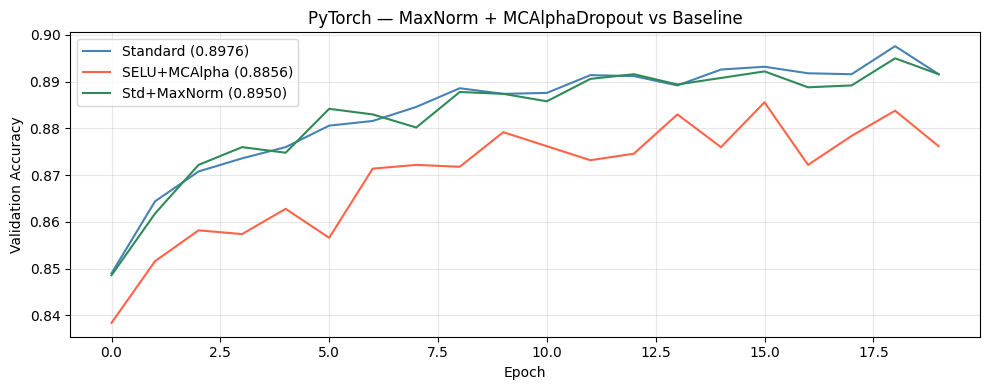

In [11]:
class StandardNetPT(nn.Module):
    """Baseline: ReLU + BatchNorm + standard Dropout."""
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.BatchNorm1d(300), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(300, 200), nn.BatchNorm1d(200), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(200, 100), nn.BatchNorm1d(100), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(100, n_classes)
        )
    def forward(self, x): return self.net(x)


def train_pt(model_factory, label, epochs=20,
             apply_maxnorm=False, max_norm_val=2.0):
    torch.manual_seed(42)
    model     = model_factory().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    hist      = {'val_acc': []}

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()

            # Apply max-norm constraint after each weight update
            if apply_maxnorm:
                for m in model.modules():
                    if isinstance(m, nn.Linear):
                        apply_max_norm_(m, max_norm=max_norm_val)

        # Eval — MCAlphaDropout stays active, so use multiple passes
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        val_acc  = correct / total
        best_acc = max(best_acc, val_acc)
        hist['val_acc'].append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | val={val_acc:.4f}')

    print(f'[{label}] Best val acc: {best_acc:.4f}\n')
    return hist, best_acc


print('Training Standard (ReLU + BN + Dropout)...')
hist_std_pt, acc_std_pt = train_pt(
    StandardNetPT, 'Standard (BN + Dropout)', epochs=20
)

print('Training SELU + MCAlphaDropout...')
hist_selu_pt, acc_selu_pt = train_pt(
    SELUNetPT, 'SELU + MCAlphaDropout', epochs=20
)

print('Training Standard + MaxNorm constraint...')
hist_mn_pt, acc_mn_pt = train_pt(
    StandardNetPT, 'Standard + MaxNorm(2.0)', epochs=20,
    apply_maxnorm=True, max_norm_val=2.0
)

plt.figure(figsize=(10, 4))
plt.plot(hist_std_pt['val_acc'],  color='steelblue',  label=f'Standard ({acc_std_pt:.4f})')
plt.plot(hist_selu_pt['val_acc'], color='tomato',     label=f'SELU+MCAlpha ({acc_selu_pt:.4f})')
plt.plot(hist_mn_pt['val_acc'],   color='seagreen',   label=f'Std+MaxNorm ({acc_mn_pt:.4f})')
plt.title('PyTorch — MaxNorm + MCAlphaDropout vs Baseline')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### MCAlphaDropout

| Aspect | Standard AlphaDropout | MCAlphaDropout |
|---|---|---|
| Training | Active | Active |
| Inference | **OFF** | **Always ON** |
| Designed for | SELU networks | SELU networks |
| Gives uncertainty? | No | Yes |
| Preserves mean/var? | Yes | Yes |

### MaxNormDense

| Aspect | L2 Regularization | Max-Norm Constraint |
|---|---|---|
| Type | Soft penalty | Hard constraint |
| Mechanism | Adds to loss | Clips weights post-update |
| Effect | Shrinks weights | Clips norm to ceiling |
| Works best with | General purpose | High dropout rates |
| Keras | `kernel_regularizer=l2()` | `kernel_constraint=MaxNorm()` |
| PyTorch | `weight_decay` in optimizer | Manual `apply_max_norm_()` call |

### SELU Network Requirements
```
1. Activation    : selu  (NOT relu, tanh, sigmoid)
2. Initializer   : lecun_normal  (NOT he_normal or glorot)
3. Dropout       : AlphaDropout  (NOT standard Dropout)
4. Normalization : NOT needed — SELU self-normalizes
5. Input         : MUST be standardized (zero mean, unit variance)
```

**Next: Notebook 18** — Custom Loss Function & Custom Metric
